In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
# preload once outside
set_seed(0)
preloaded = {}
clutter_files = [
    os.path.join(clutter_dir, f)
    for f in os.listdir(clutter_dir)
    if os.path.isfile(os.path.join(clutter_dir, f))
]
for f in tqdm(clutter_files, desc="Preloading"):
    C_complex = read_mstar_clutter_complex(f)
    C_raw = Magnitude()(C_complex)
    preloaded[f] = LogMapping(c=1000.0)(C_raw)

clutter_cache = build_clutter_cache(meas_ds, clutter_dir, preloaded = preloaded)

Building clutter cache: 100%|███████████████████████████████████████████████████████| 1345/1345 [00:54<00:00, 24.69it/s]


In [7]:
meas_ds_s2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache, preloaded = preloaded), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [8]:
train_ds = synth_ds
test_ds = meas_ds_s2

In [9]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [10]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.8230
Evaluating Run 1: seed 42
Test Accuracy: 0.8394
Evaluating Run 2: seed 100
Test Accuracy: 0.8230
Evaluating Run 3: seed 123
Test Accuracy: 0.8141
Evaluating Run 4: seed 666
Test Accuracy: 0.7762
Evaluating Run 5: seed 777
Test Accuracy: 0.8208
Evaluating Run 6: seed 849
Test Accuracy: 0.8290
Evaluating Run 7: seed 1000
Test Accuracy: 0.8126
Evaluating Run 8: seed 1111
Test Accuracy: 0.8230
Evaluating Run 9: seed 1234
Test Accuracy: 0.8320


In [11]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 77.6208
Max: 83.9405
Avg, Std: 81.9331, 1.6221


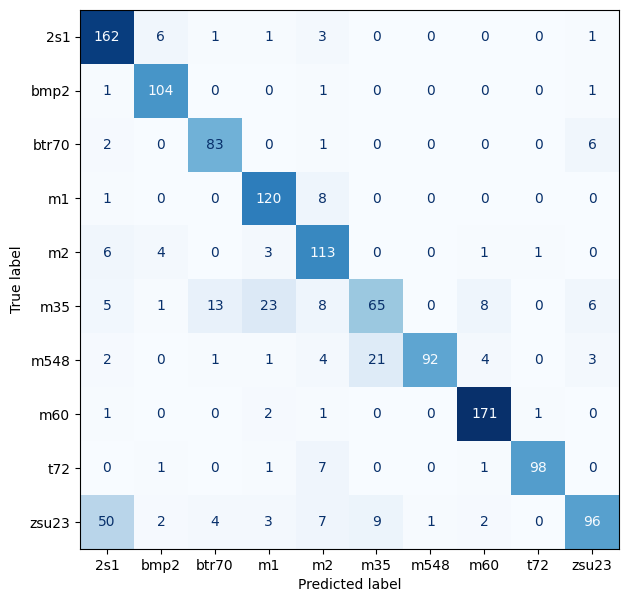

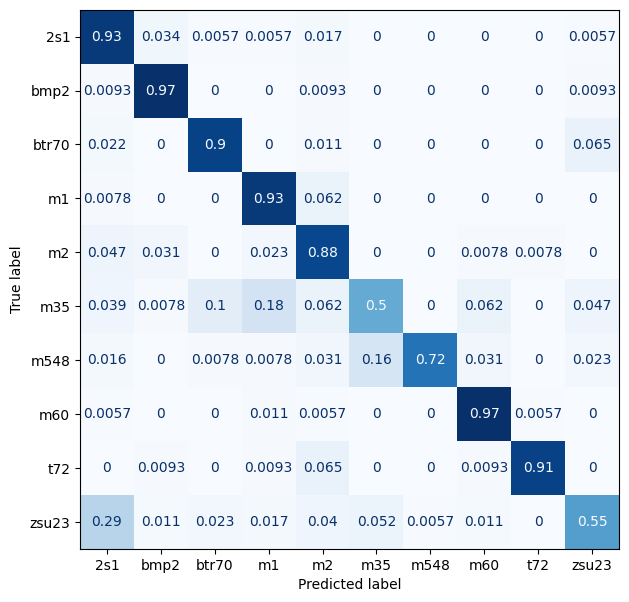

In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed777_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()
plt.show()

In [12]:
combined_ds = ConcatDataset([no_aug_synth_ds, meas_ds_s2])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

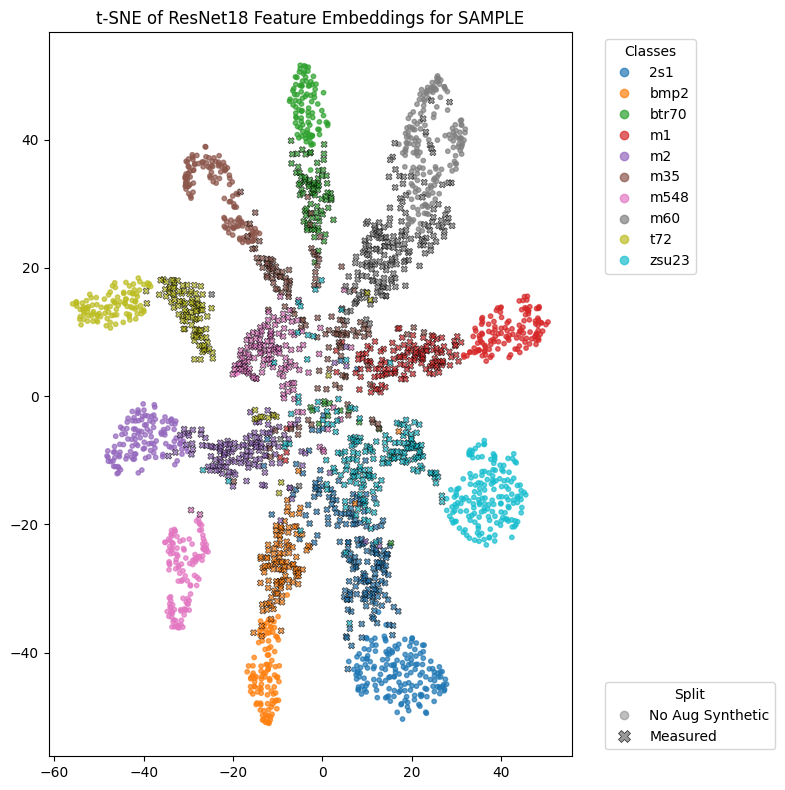

In [15]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed777_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 03:10:35.606] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


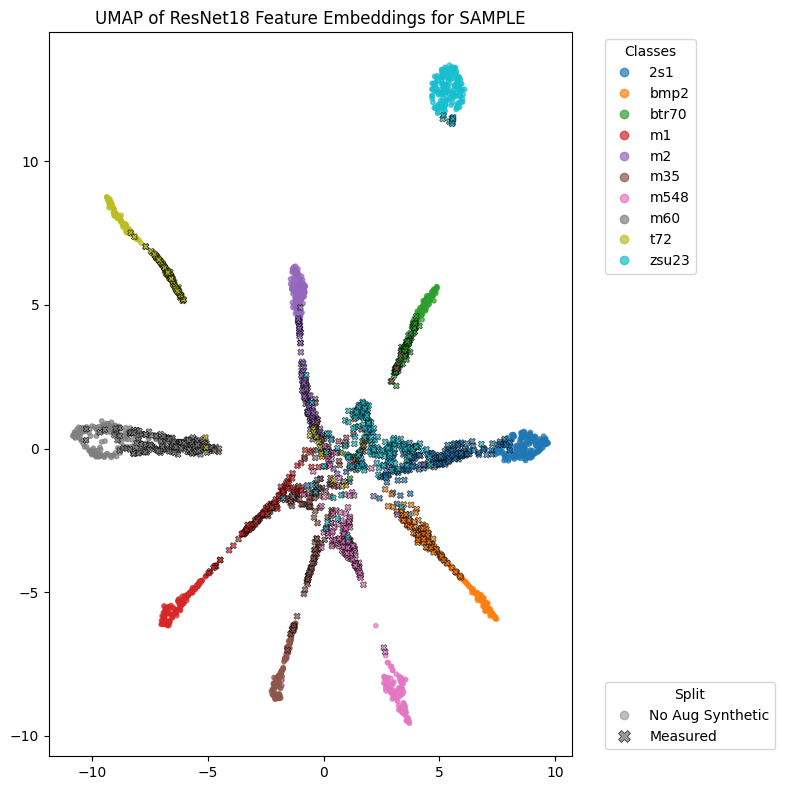

In [16]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed777_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [7]:
save_dir = os.path.join(workspace, "images", "comparison")
os.makedirs(save_dir, exist_ok=True)

for idx in tqdm(range(len(meas_ds)), desc="Saving plots"):
    
    tensor1, label1 = meas_ds[idx]
    image1 = tensor1[0].numpy()  # (3, 128, 128) -> (128, 128)
    class_name1 = meas_ds.classes[label1]

    tensor2, label2 = meas_ds_s2[idx]
    image2 = tensor2[0].numpy()  # (3, 128, 128) -> (128, 128)
    class_name2 = meas_ds_s2.classes[label2]
    
    fig = plt.figure(figsize = (10, 4))
    
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image1, cmap='gray')
    ax1.set_title(f"sample clutter")
    ax1.axis('off')

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(image2, cmap='gray')
    ax2.set_title(f"mstar clutter")
    ax2.axis('off')

    if class_name1 == class_name2:
        save_path = os.path.join(save_dir, f"{idx:04d}_{class_name1}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=80)
        plt.close(fig)

print(f"Saved {len(meas_ds)} images to {save_dir}")

Saving plots: 100%|█████████████████████████████████████████████████████████████████| 1345/1345 [06:18<00:00,  3.55it/s]

Saved 1345 images to /mnt/d/Users/Admin/Projects/dso/SAR_ML/images/comparison
